# Sobre o Dataset

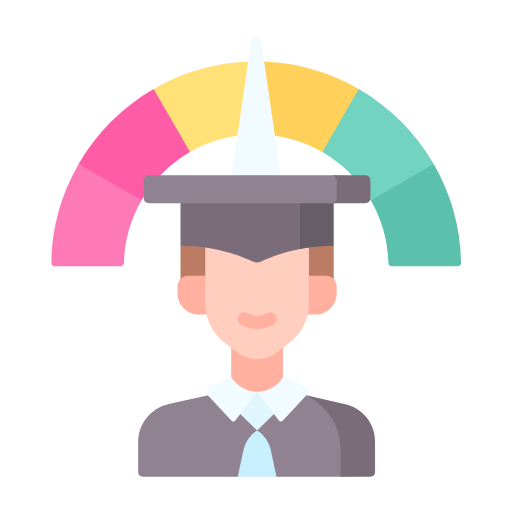

Neste estudo de Regressão Linear, usaremos o dataset de [Student Performance ](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)disponível no Kaggle. A ideia do conjunto de dados, segundo o autor, é examinar fatores que determinam a perfornace acadêmica do aluno.

Para isso, o conjunto conta com 10.000 registros com as seguintes variáveis:

- **Horas de Estudo**: quantidade de horas que o aluno investe nos estudos.
- **Pontuações Anteriores**: pontuação obtidas em outros testes.
- **Atividadees Extracurriculares**: diz se o aluno participa de atividades extracurriculares ou não.
- **Horas de Sono**: média de horas de sono que o aluno tem por dia.
- **Questões de Exemplo Praticadas**: número de questões que o aluno respondeu nos estudos.
- **Índice de Desepenho**: variável alvo que carrega o desempenho acadêmico médio do aluno.  

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")
print("Path to dataset files:", path)
!ls {path}

Path to dataset files: /kaggle/input/student-performance-multiple-linear-regression
Student_Performance.csv


In [ ]:
import pandas as pd

dataset = pd.read_csv(f'{path}/Student_Performance.csv')
dataset.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Explorando o Dataset

Nessa etapa, vamos explorar dado a dado a fim de conhecer os por menores do conjunto de dados para tarefa de regressão.

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


Vemos que dos 10 mil registros em cada uma das variáveis, não temos registros nulos, caracterizando o conjunto de dados como completo. Além disso, das variáveis preditoras, temos 4 numéricas e uma categórica. Já a variável alvo, apresenta-se como númerica discreta.

In [ ]:
dataset.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


A análise descritiva revela que os estudantes estudam em média cerca de 5 horas por dia, com uma dispersão moderada, variando de 1 a 9 horas. A maioria se concentra entre 3 e 7 horas de estudo. As notas anteriores possuem média em torno de 69, com variabilidade baixa a moderada, indicando que a maioria dos estudantes apresenta desempenho acadêmico razoavelmente homogêneo, sem grandes desvios. O padrão de sono é bastante consistente, com a maioria dormindo entre 6 e 7 horas, e pouca variação entre os estudantes. A quantidade de provas práticas realizadas varia bastante: enquanto alguns alunos não praticam nenhuma, outros chegam a praticar até 9 provas, evidenciando alta variabilidade nesse aspecto. O índice de desempenho final dos estudantes apresenta uma dispersão moderada, com valores que vão de 10 a 100, indicando a presença de estudantes com desempenhos muito baixos e outros com desempenhos muito altos. De forma geral, estudo e sono apresentam padrões regulares, enquanto a prática de provas é a variável com maior diferença entre os indivíduos.

In [ ]:
dataset.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


Vemos aqui que não há valores faltantes, corroborando a completudo do conjunto de dados.

## Horas de Estudo

In [ ]:
dataset['Hours Studied'].value_counts().sort_index()

,count
Hours Studied,
1,1152
2,1085
3,1119
4,1085
5,1094
6,1133
7,1129
8,1088
9,1115


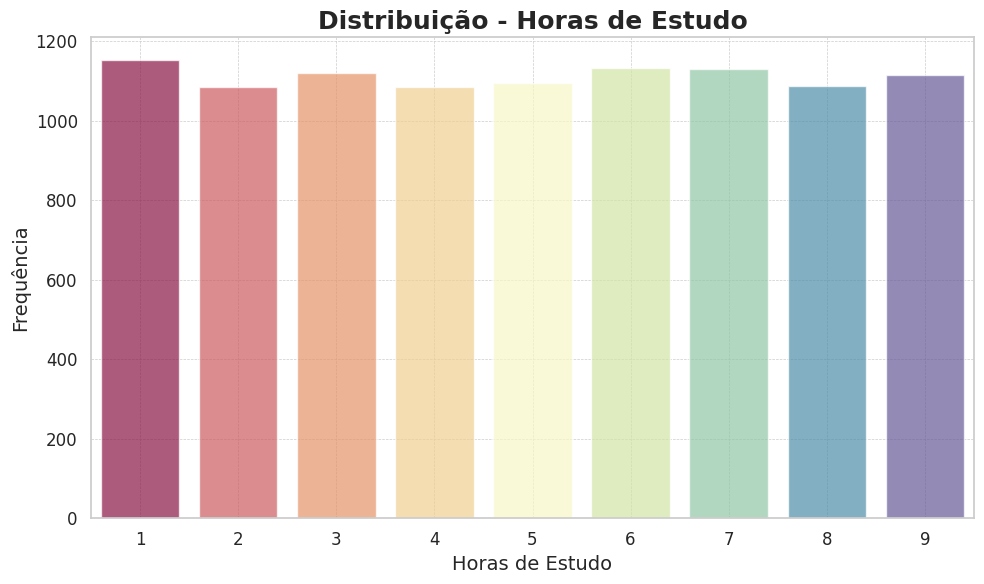

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=dataset,
    x='Hours Studied',
    hue='Hours Studied',
    order=dataset['Hours Studied'].value_counts().sort_index().index,
    palette="Spectral",
    dodge=False,
    alpha=0.7,
    ax=ax
)

ax.legend_.remove()

ax.set_title("Distribuição - Horas de Estudo", fontsize=18, fontweight="bold")
ax.set_xlabel("Horas de Estudo", fontsize=14)
ax.set_ylabel("Frequência", fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

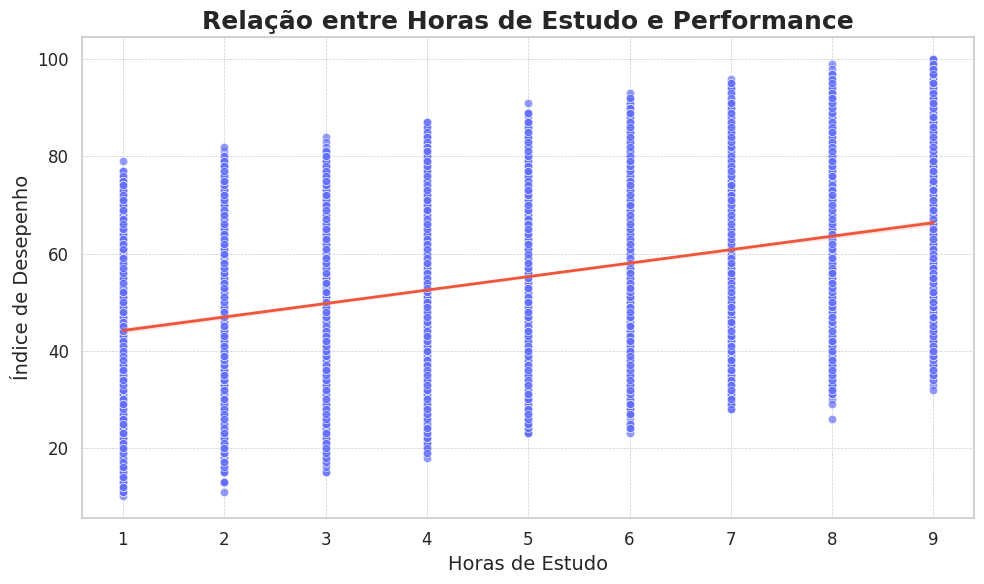

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=dataset,
    x='Hours Studied',
    y='Performance Index',
    color="#636EFA",
    alpha=0.7,
    ax=ax
)

sns.regplot(
    data=dataset,
    x='Hours Studied',
    y='Performance Index',
    scatter=False,
    color="#EF553B",
    line_kws={'linewidth':2},
    ax=ax
)

ax.set_title("Relação entre Horas de Estudo e Performance", fontsize=18, fontweight="bold")
ax.set_xlabel("Horas de Estudo", fontsize=14)
ax.set_ylabel("Índice de Desepenho", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Vemos que, dentro do conjunto de dados, os registros de horas de estudos estão quase que uniformimente distribuídos. Em relação à variável alvo, apesar de apontar que mais horas de estudo influenciam positivamente na perfomance, isso não parece ser uma regra geral, configurando uma correlação positiva fraca.

## Pontuações Anteriores

In [ ]:
dataset['Previous Scores'].value_counts()

,count
Previous Scores,
54,216
87,208
56,192
62,184
89,182
53,181
60,181
77,181
52,176


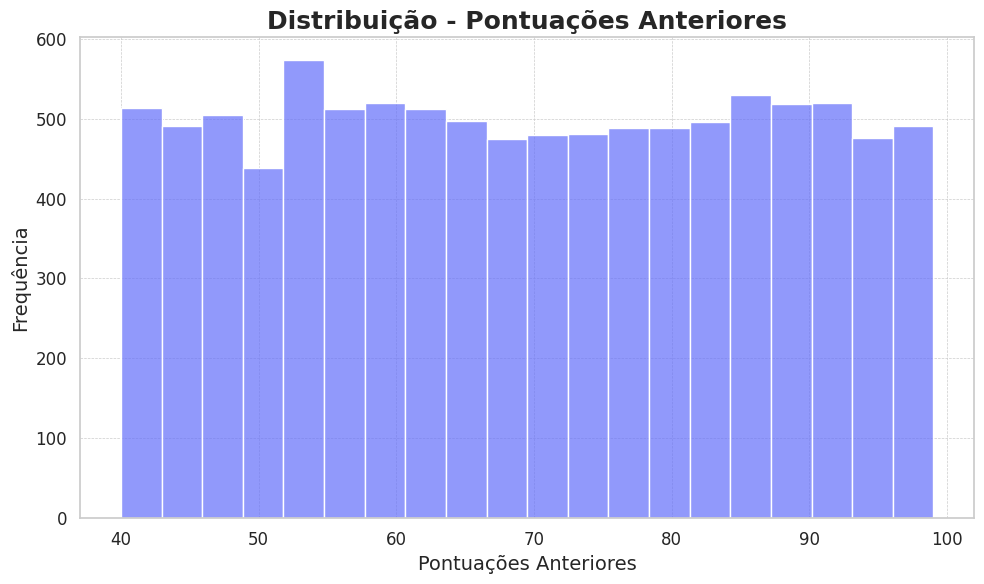

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=dataset,
    x='Previous Scores',
    color="#636EFA",
    alpha=0.7,
    bins=20,
    ax=ax
)

ax.set_title("Distribuição - Pontuações Anteriores", fontsize=18, fontweight="bold")
ax.set_xlabel("Pontuações Anteriores", fontsize=14)
ax.set_ylabel("Frequência", fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

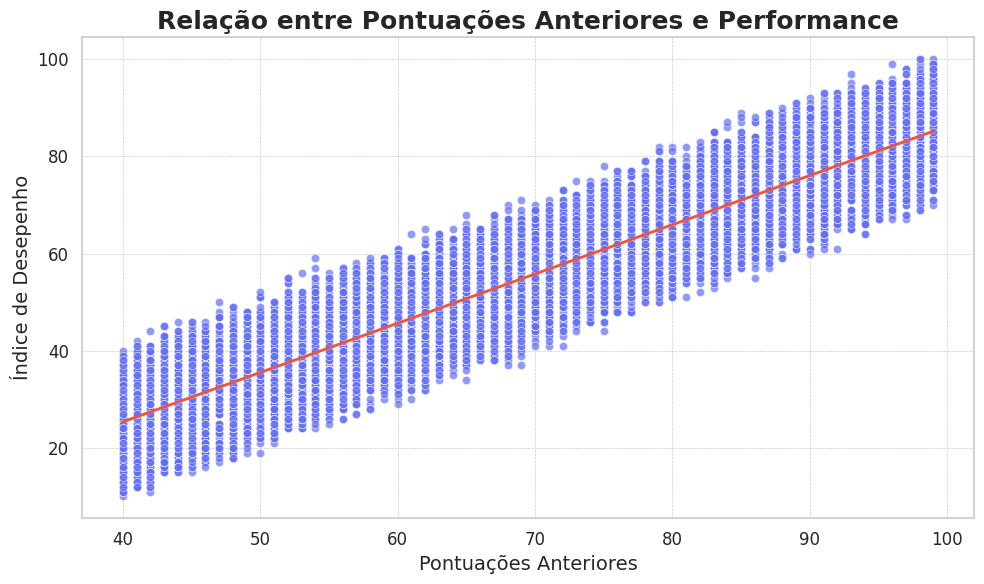

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=dataset,
    x='Previous Scores',
    y='Performance Index',
    color="#636EFA",
    alpha=0.7,
    ax=ax
)

sns.regplot(
    data=dataset,
    x='Previous Scores',
    y='Performance Index',
    scatter=False,
    color="#EF553B",
    line_kws={'linewidth':2},
    ax=ax
)

ax.set_title("Relação entre Pontuações Anteriores e Performance", fontsize=18, fontweight="bold")
ax.set_xlabel("Pontuações Anteriores", fontsize=14)
ax.set_ylabel("Índice de Desepenho", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Assim como a variável anterior (Horas de Estudo), os dados registrados de Pontuações Anteriores parecem estar uniformimente distribuidos. Quanto a sua relação com a Performance, apesar de alguma variância, o gráfico aponta uma correlação positiva. Aparentemente, está variável tem caracaterística explicativa para o resultado dos estudantes, sendo importante no modelo de regressão.

## Extracurricular Activities

In [ ]:
dataset['Extracurricular Activities'].value_counts()

,count
Extracurricular Activities,
No,5052
Yes,4948


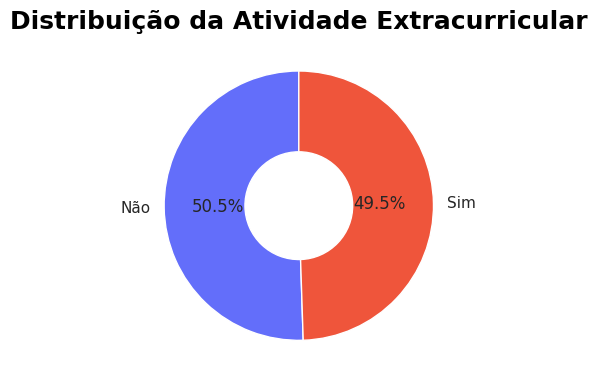

In [ ]:
grouped_data = dataset['Extracurricular Activities'].value_counts().reset_index()
grouped_data.columns = ['Extracurricular Activities', 'Count']

map_labels = {"No": "Não", "Yes": "Sim"}
grouped_data["Label"] = grouped_data['Extracurricular Activities'].map(map_labels)

colors = {
    "Não": "#636EFA",
    "Sim": "#EF553B"
}

fig, ax = plt.subplots(figsize=(6, 4))

ax.pie(
    grouped_data["Count"],
    labels=grouped_data["Label"],
    colors=[colors[label] for label in grouped_data["Label"]],
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white'),
    autopct='%1.1f%%'
)

ax.set_title("Distribuição da Atividade Extracurricular", fontsize=18, fontweight="bold", color="black")

plt.tight_layout()
plt.show()

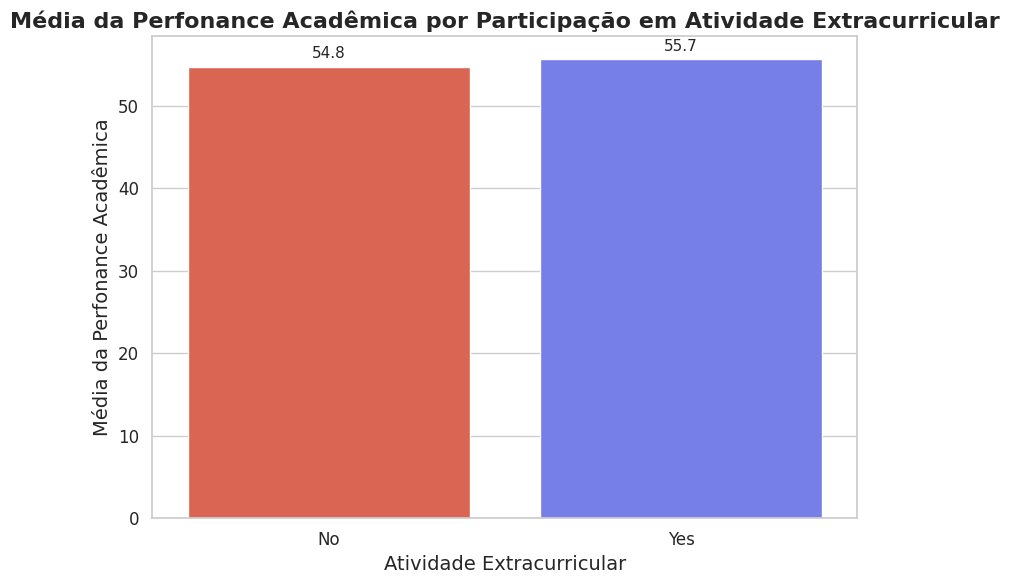

In [ ]:
column = "Extracurricular Activities"
target = "Performance Index"

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))

mean_target = dataset.groupby(column)[target].mean().reindex(["No", "Yes"]).reset_index()

sns.barplot(
    data=mean_target,
    x=column,
    y=target,
    hue=column,
    palette={"Yes": "#636EFA", "No": "#EF553B"},
    dodge=False,
    ax=ax,
    legend=False
)

ax.set_title("Média da Perfonance Acadêmica por Participação em Atividade Extracurricular", fontsize=16, fontweight="bold")
ax.set_xlabel("Atividade Extracurricular", fontsize=14)
ax.set_ylabel("Média da Perfonance Acadêmica", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

Vemos mais uma vez uma distriubição uniforme entre as categorias da variavel de Atividade Extracurricular. Complementar a isso, na média, não há uma diferença expressiva na perfornance para quem não pratica ou pratica atividade extracurricular nesse conjunto de dados com leve vantagem para quem se propõe a realizar outras atividades fora das obrigações escolares.

## Horas de Sono

In [ ]:
dataset['Sleep Hours'].value_counts().sort_index()

,count
Sleep Hours,
4,1619
5,1606
6,1673
7,1676
8,1804
9,1622


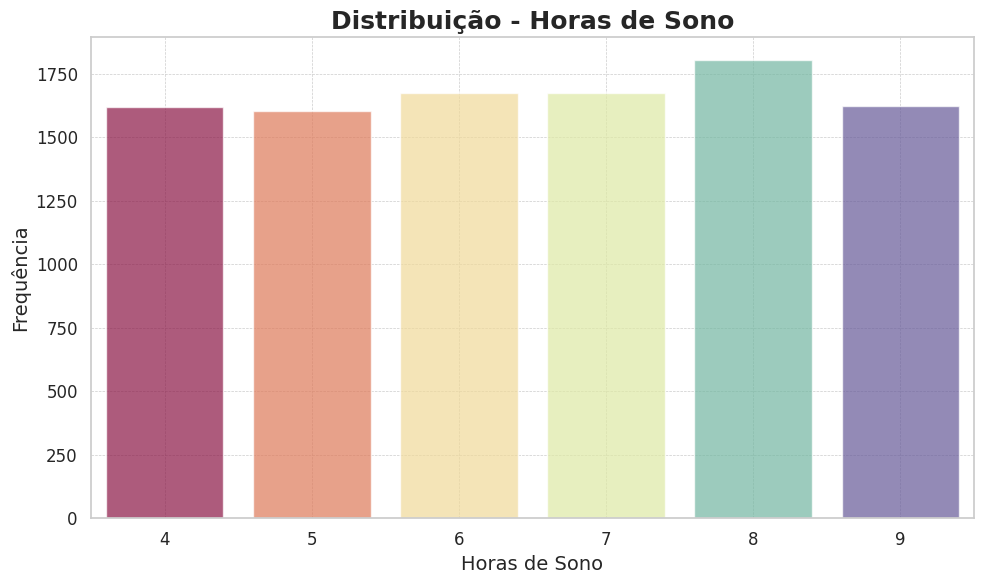

In [ ]:
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=dataset,
    x='Sleep Hours',
    hue='Sleep Hours',
    order=dataset['Sleep Hours'].value_counts().sort_index().index,
    palette='Spectral',
    dodge=False,
    alpha=0.7,
    ax=ax
)

ax.legend_.remove()

ax.set_title('Distribuição - Horas de Sono', fontsize=18, fontweight='bold')
ax.set_xlabel('Horas de Sono', fontsize=14)
ax.set_ylabel('Frequência', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

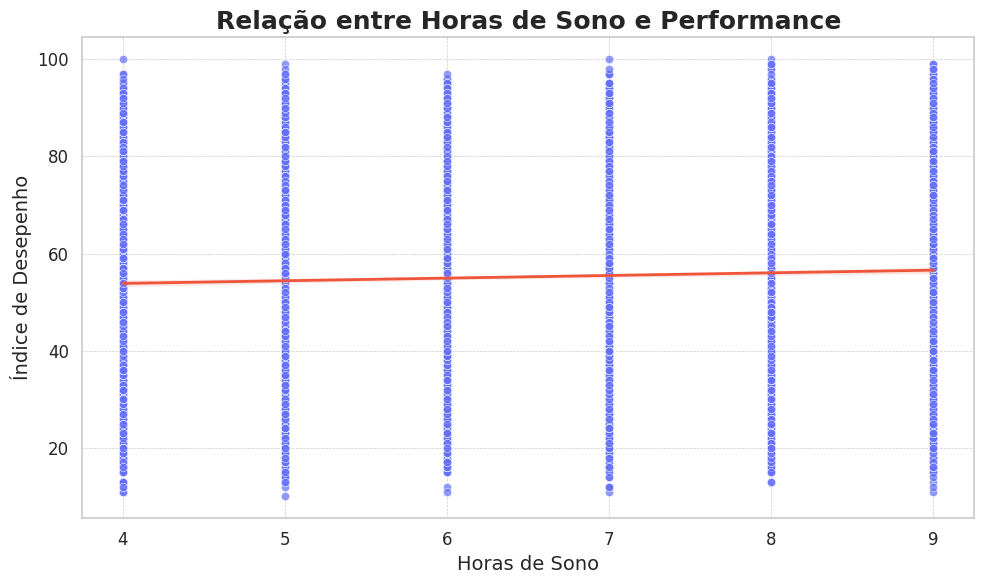

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=dataset,
    x='Sleep Hours',
    y='Performance Index',
    color="#636EFA",
    alpha=0.7,
    ax=ax
)

sns.regplot(
    data=dataset,
    x='Sleep Hours',
    y='Performance Index',
    scatter=False,
    color="#EF553B",
    line_kws={'linewidth':2},
    ax=ax
)

ax.set_title("Relação entre Horas de Sono e Performance", fontsize=18, fontweight="bold")
ax.set_xlabel("Horas de Sono", fontsize=14)
ax.set_ylabel("Índice de Desepenho", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Como em outras variáveis, há uma distribuição uniforma dos valores das horas de sono. Em relação à performance acadêmica, há uma variação grande entre os valores e, por mais que mais horas de sono tenha uma leve influência positiva nos resultados de performance, essa não é uma variável que explica o resultado, pelo menos não sozinha.

## Questões de Exemplo Praticadas

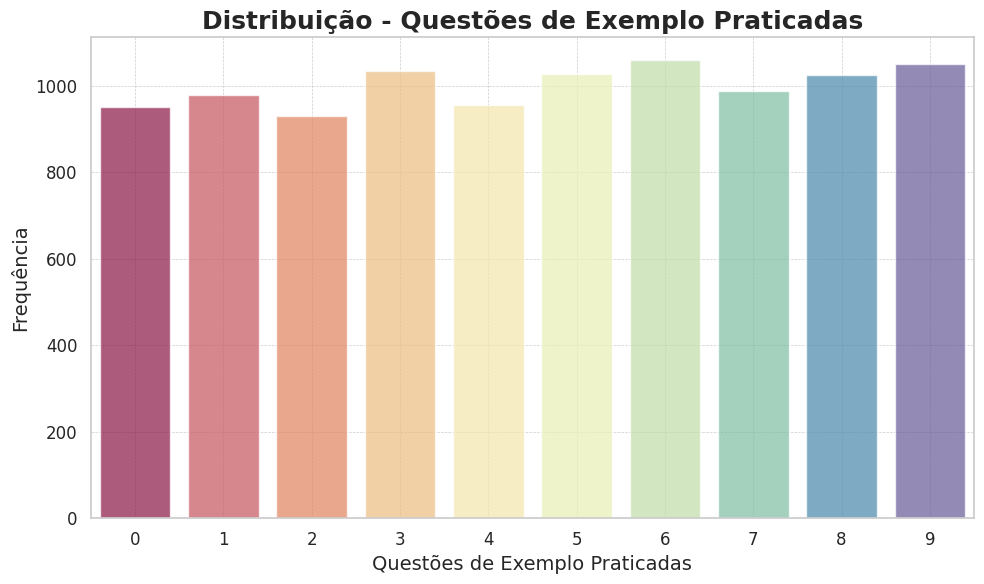

In [ ]:
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=dataset,
    x='Sample Question Papers Practiced',
    hue='Sample Question Papers Practiced',
    order=dataset['Sample Question Papers Practiced'].value_counts().sort_index().index,
    palette='Spectral',
    dodge=False,
    alpha=0.7,
    ax=ax
)

ax.legend_.remove()

ax.set_title('Distribuição - Questões de Exemplo Praticadas', fontsize=18, fontweight='bold')
ax.set_xlabel('Questões de Exemplo Praticadas', fontsize=14)
ax.set_ylabel('Frequência', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

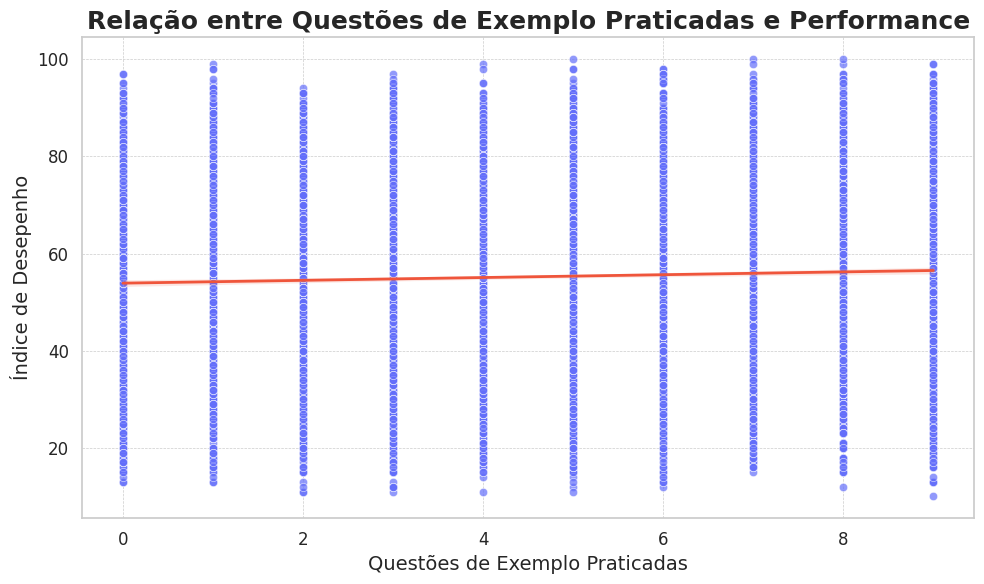

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=dataset,
    x='Sample Question Papers Practiced',
    y='Performance Index',
    color="#636EFA",
    alpha=0.7,
    ax=ax
)

sns.regplot(
    data=dataset,
    x='Sample Question Papers Practiced',
    y='Performance Index',
    scatter=False,
    color="#EF553B",
    line_kws={'linewidth':2},
    ax=ax
)

ax.set_title("Relação entre Questões de Exemplo Praticadas e Performance", fontsize=18, fontweight="bold")
ax.set_xlabel("Questões de Exemplo Praticadas", fontsize=14)
ax.set_ylabel("Índice de Desepenho", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Índice de Desepenho

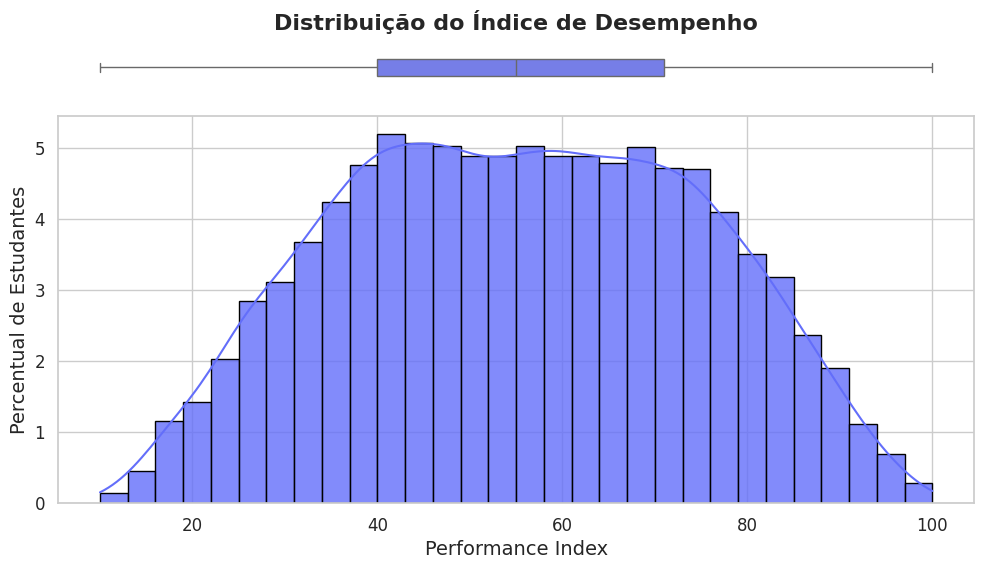

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=dataset,
    x="Performance Index",
    bins=30,
    kde=True,
    stat="percent",
    color="#636EFA",
    edgecolor="black",
    alpha=0.8,
    ax=ax
)

box_ax = ax.inset_axes([0, 1.05, 1, 0.15], sharex=ax)
sns.boxplot(
    data=dataset,
    x="Performance Index",
    ax=box_ax,
    color="#636EFA",
    width=0.3
)
box_ax.axis("off")

ax.set_title("Distribuição do Índice de Desempenho", fontsize=16, fontweight="bold")
ax.set_xlabel("Performance Index", fontsize=14)
ax.set_ylabel("Percentual de Estudantes", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

A distribuição do desempenho acadêmico dos estudantes é aproximadamente simétrica, centrada na faixa de 50 a 70 pontos. Isso indica que a maioria apresenta desempenho médio, com poucos estudantes em extremos muito baixos ou muito altos. A forma da curva sugere boa homogeneidade na turma, com pequena dispersão nos desempenhos.

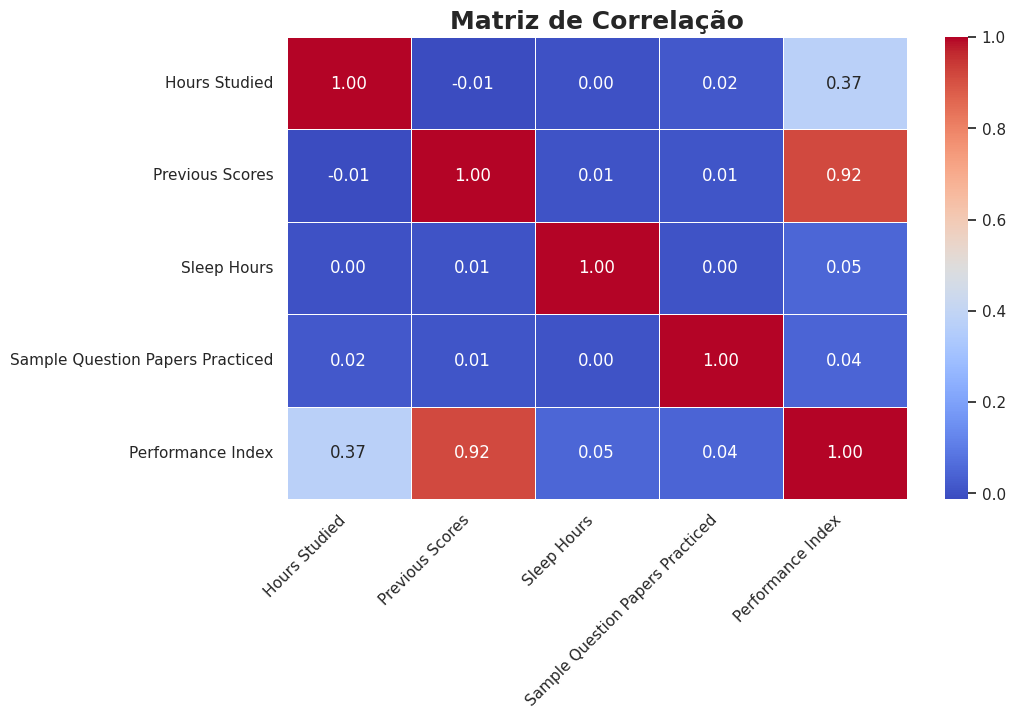

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    data=dataset.select_dtypes(exclude=object).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de Correlação", fontsize=18, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.show()

O desempenho acadêmico está fortemente associado às notas anteriores e, em menor grau, às horas de estudo. As outras variáveis, apesar de relevantes em um contexto mais amplo (como hábitos e estilo de vida), não apresentam influência linear significativa isoladamente sobre o índice de performance.

## Pré-Processamento dos Dados

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
dataset['Extracurricular Activities'] = encoder.fit_transform(dataset['Extracurricular Activities'])
dataset.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
dataset[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']] = scaler.fit_transform(dataset[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']])
dataset.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,0.775188,1.704176,1,1.456205,-1.249754,91.0
1,-0.383481,0.723913,0,-1.492294,-0.900982,65.0
2,1.161410,-1.063626,1,0.276805,-0.900982,45.0
3,0.002742,-1.005963,1,-0.902594,-0.900982,36.0
4,0.775188,0.320275,0,0.866505,0.145333,66.0


In [ ]:
X = dataset.drop('Performance Index', axis=1)
y = dataset['Performance Index']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Tamanho do conjunto de treinamento:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)
print("Tamanho do vetor de treinamento:", y_train.shape)
print("Tamanho do vetor de teste:", y_test.shape)

Tamanho do conjunto de treinamento: (8000, 5)
Tamanho do conjunto de teste: (2000, 5)
Tamanho do vetor de treinamento: (8000,)
Tamanho do vetor de teste: (2000,)


## Regressão Linear Múltipla

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

MSE (Erro Quadrático Médio): 4.0826
R² (Coeficiente de Determinação): 0.9890


## Avaliação do Modelo

In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)

model_sm = sm.OLS(y_train, X_train_const).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:      Performance Index   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.398e+05
Date:                Sat, 26 Apr 2025   Prob (F-statistic):               0.00
Time:                        00:23:49   Log-Likelihood:                -17063.
No. Observations:                8000   AIC:                         3.414e+04
Df Residuals:                    7994   BIC:                         3.418e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

O modelo de regressão linear múltipla ajustado para o conjunto de treino apresentou um excelente desempenho. O coeficiente de determinação (R²) foi de 0,989, indicando que aproximadamente 98,9% da variação no índice de desempenho acadêmico dos estudantes é explicada pelas variáveis independentes analisadas. O R² ajustado manteve o mesmo valor, demonstrando que o modelo permanece altamente explicativo mesmo considerando o número de variáveis.

Todas as variáveis incluídas — horas estudadas, notas anteriores, participação em atividades extracurriculares, horas de sono e número de provas praticadas — mostraram-se estatisticamente significativas (p-valor < 0.001), reforçando sua relevância para explicar o desempenho dos estudantes.

Entre as variáveis, Previous Scores e Hours Studied destacaram-se como os fatores de maior impacto positivo sobre o desempenho. As variáveis Sleep Hours, Sample Question Papers Practiced e Extracurricular Activities também apresentaram efeitos positivos, embora de magnitude menor.

O diagnóstico dos resíduos confirma a adequação do modelo. O teste de Omnibus apresentou um p-valor de 0.096 e o teste de Jarque-Bera um p-valor de 0.0825, indicando que não há evidências suficientes para rejeitar a hipótese de normalidade dos resíduos. Além disso, o valor de Durbin-Watson de 2.033 sugere ausência de autocorrelação dos erros, reforçando a confiabilidade das inferências.

Portanto, conclui-se que o modelo ajustado é estatisticamente robusto, bem ajustado aos dados de treino e adequado para previsão do índice de desempenho acadêmico com base nas variáveis estudadas.

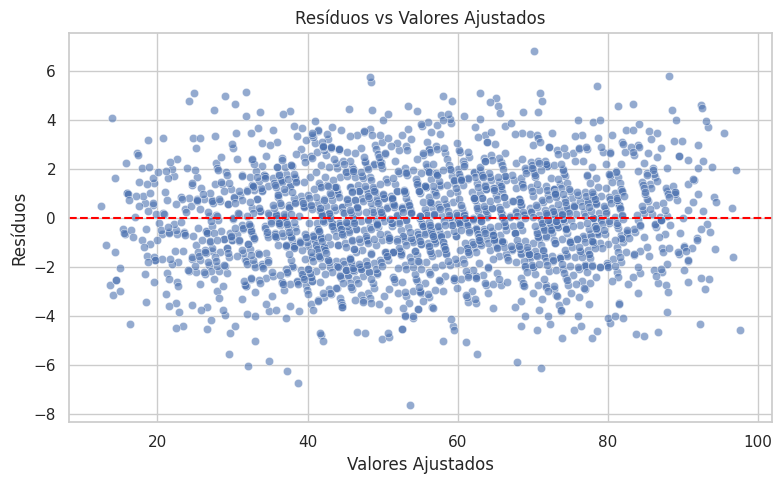

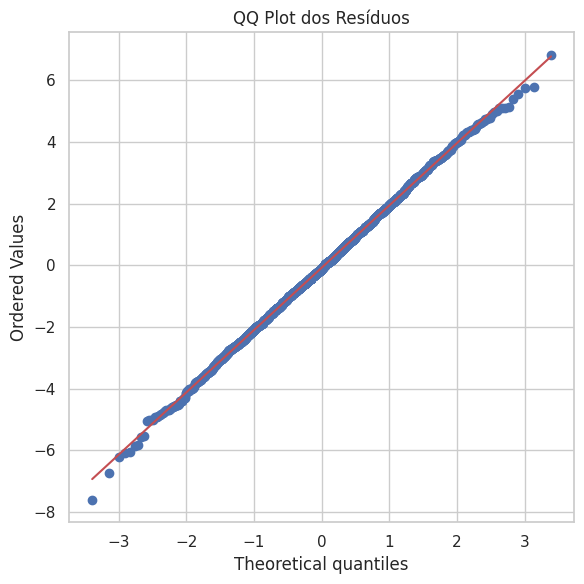

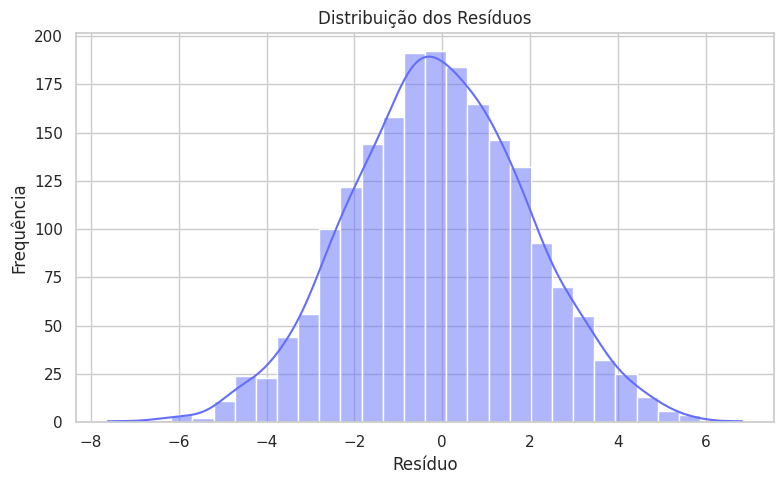

In [ ]:
import scipy.stats as stats

residuals = y_test - y_pred

# 1. Resíduos vs Valores Ajustados
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos vs Valores Ajustados")
plt.xlabel("Valores Ajustados")
plt.ylabel("Resíduos")
plt.tight_layout()
plt.show()

# 2. QQ-plot dos resíduos (verifica normalidade)
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot dos Resíduos")
plt.tight_layout()
plt.show()

# 3. Histograma com curva de densidade dos resíduos
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color="#636EFA")
plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

A avaliação gráfica dos resíduos do modelo de regressão linear múltipla indica que as principais suposições estatísticas foram atendidas, reforçando a qualidade do ajuste obtido.

No gráfico de dispersão dos resíduos em relação aos valores ajustados, observa-se que os pontos estão distribuídos aleatoriamente ao redor da linha zero, sem a presença de padrões sistemáticos ou tendência de funil. Isso sugere que os resíduos apresentam homocedasticidade (variância constante) e independência em relação às predições.

O QQ plot dos resíduos mostra que os pontos seguem de forma bastante próxima a linha teórica de normalidade, com apenas leves desvios nas extremidades, o que é esperado em amostras grandes. Isso indica que os resíduos seguem uma distribuição aproximadamente normal.

Por fim, o histograma com curva de densidade reforça essa percepção, revelando uma distribuição simétrica, centrada no zero, e sem caudas longas ou assimetrias marcantes.

Dessa forma, os gráficos confirmam que as suposições de normalidade, homocedasticidade e aleatoriedade dos resíduos são atendidas, validando o uso da regressão linear como modelo apropriado para os dados em questão.

In [ ]:
import joblib

joblib.dump(model, 'model.pkl')

In [ ]:
coef_table = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": model.coef_
})

intercept = pd.DataFrame({
    "Variable": ["Intercept"],
    "Coefficient": [model.intercept_]
})

coef_table = pd.concat([intercept, coef_table], ignore_index=True)
coef_table = coef_table.round(4)

print(coef_table)

                           Variable  Coefficient
0                         Intercept     -33.9219
1                     Hours Studied       2.8525
2                   Previous Scores       1.0170
3        Extracurricular Activities       0.6086
4                       Sleep Hours       0.4769
5  Sample Question Papers Practiced       0.1918


$$
\text{Performance Index} = 54.9215 + 7.3869 \times \text{Hours Studied} + 17.6620 \times \text{Previous Scores} + 0.6129 \times \text{Extracurricular Activities} + 0.8149 \times \text{Sleep Hours} + 0.5557 \times \text{Sample Question Papers Practiced}
$$
